# 02 — The Three Kings

This notebook analyzes how Reddit talks about the three legends of Indian cricket - MS Dhoni, Virat Kohli, and Rohit Sharma - across cricket subreddits between June 2023 and July 2024.

### 1. Setup

Import utilities and start Spark.

In [1]:
import sys
sys.path.insert(0, "..")

from utils import (
    get_spark, load_cricket_submissions, load_cricket_comments,
    add_player_mentions, add_time_features, save_figure, save_pandas_to_local,
    EVENT_DATES,
)

from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, avg, sum as ssum, when, lower
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd

# Plot style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120


### 2. Start Spark

In [2]:
# Start Spark
spark = get_spark("02_ThreeKings")
spark


:: loading settings :: url = jar:file:/home/ubuntu/spark-3.5.1-bin-hadoop3/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ubuntu/.ivy2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-fc8aea62-0139-42db-8917-3c3ae39dd7de;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 405ms :: artifacts dl 20ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evi

### 3. Load filtered submissions

Load the cricket-filtered submissions saved in notebook 01.

In [3]:
# Load filtered cricket submissions
subs = load_cricket_submissions(spark)
print(f"Submissions loaded")
subs.printSchema()


26/04/28 17:47:56 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Submissions loaded
root
 |-- author: string (nullable = true)
 |-- author_flair_css_class: string (nullable = true)
 |-- author_flair_text: string (nullable = true)
 |-- created_utc: long (nullable = true)
 |-- distinguished: string (nullable = true)
 |-- domain: string (nullable = true)
 |-- edited: double (nullable = true)
 |-- id: string (nullable = true)
 |-- is_self: boolean (nullable = true)
 |-- locked: boolean (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- over_18: boolean (nullable = true)
 |-- quarantine: boolean (nullable = true)
 |-- retrieved_on: long (nullable = true)
 |-- score: long (nullable = true)
 |-- selftext: string (nullable = true)
 |-- stickied: boolean (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- subreddit_id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- url: string (nullable = true)
 |-- yyyy: integer (nullable = true)
 |-- mm: integer (nullable = true)



### 4. Load filtered comments

Load the cricket-filtered comments.

In [4]:
# Load filtered cricket comments
coms = load_cricket_comments(spark)
print(f"Comments loaded")


Comments loaded


### 5. Add time features

Add hour, day, month, year columns from the Unix timestamp.

In [5]:
# Add time columns to submissions
subs = add_time_features(subs, ts_col="created_utc")

# Add time columns to comments
coms = add_time_features(coms, ts_col="created_utc")


### 6. Add player mention flags — submissions

Tag each submission with whether it mentions Dhoni, Kohli, or Rohit.

In [6]:
# Tag player mentions in submission titles
subs = add_player_mentions(subs, text_col="title")


### 7. Add player mention flags — comments

Same for comments using the body text.

In [7]:
# Tag player mentions in comment body
coms = add_player_mentions(coms, text_col="body")


### 8. Overall player mention counts — submissions

How many posts mention each player?

In [8]:
# Count posts mentioning each player
mention_counts = subs.agg(
    ssum(col("mentions_dhoni").cast("int")).alias("Dhoni"),
    ssum(col("mentions_kohli").cast("int")).alias("Kohli"),
    ssum(col("mentions_rohit").cast("int")).alias("Rohit"),
).toPandas()

print("Player mentions in submissions:")
print(mention_counts)


Player mentions in submissions:
   Dhoni  Kohli  Rohit
0   5296   7300   9910


### 9. Overall player mention counts — comments

How many comments mention each player?

In [9]:
# Count comments mentioning each player
com_mention_counts = coms.agg(
    ssum(col("mentions_dhoni").cast("int")).alias("Dhoni"),
    ssum(col("mentions_kohli").cast("int")).alias("Kohli"),
    ssum(col("mentions_rohit").cast("int")).alias("Rohit"),
).toPandas()

print("Player mentions in comments:")
print(com_mention_counts)


Player mentions in comments:
   Dhoni  Kohli  Rohit
0  45746  88925  82198


### 10. Bar chart — player mentions in posts

Saved to results/figures/02_player_mentions_posts.png


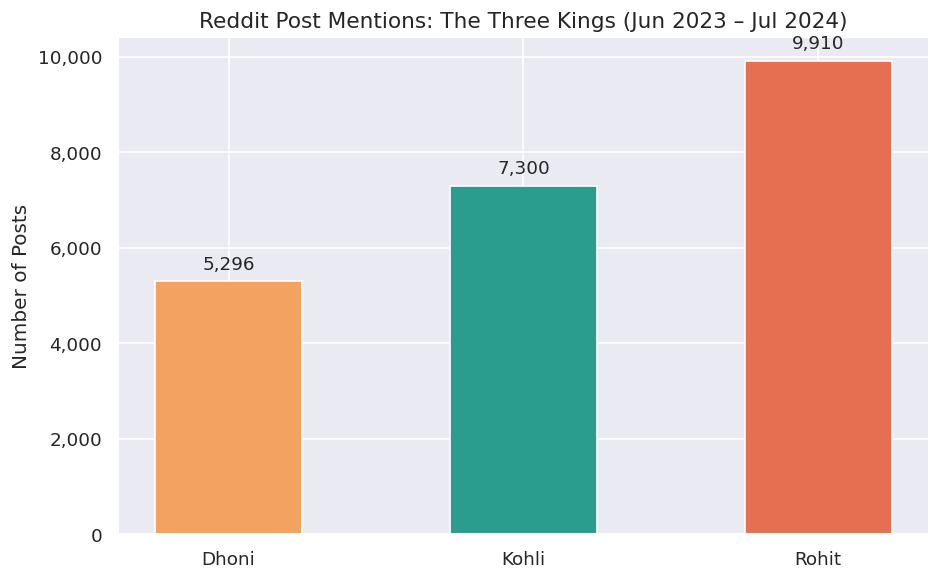

In [10]:
# Bar chart of player mentions
fig, ax = plt.subplots(figsize=(8, 5))
players = ["Dhoni", "Kohli", "Rohit"]
counts = [mention_counts["Dhoni"][0], mention_counts["Kohli"][0], mention_counts["Rohit"][0]]
colors = ["#f4a261", "#2a9d8f", "#e76f51"]

bars = ax.bar(players, counts, color=colors, width=0.5, edgecolor="white")
ax.bar_label(bars, labels=[f"{c:,}" for c in counts], padding=5, fontsize=11)
ax.set_title("Reddit Post Mentions: The Three Kings (Jun 2023 – Jul 2024)", fontsize=13)
ax.set_ylabel("Number of Posts")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
save_figure(fig, "02_player_mentions_posts.png")
plt.show()


### 11. Bar chart — player mentions in comments

Saved to results/figures/02_player_mentions_comments.png


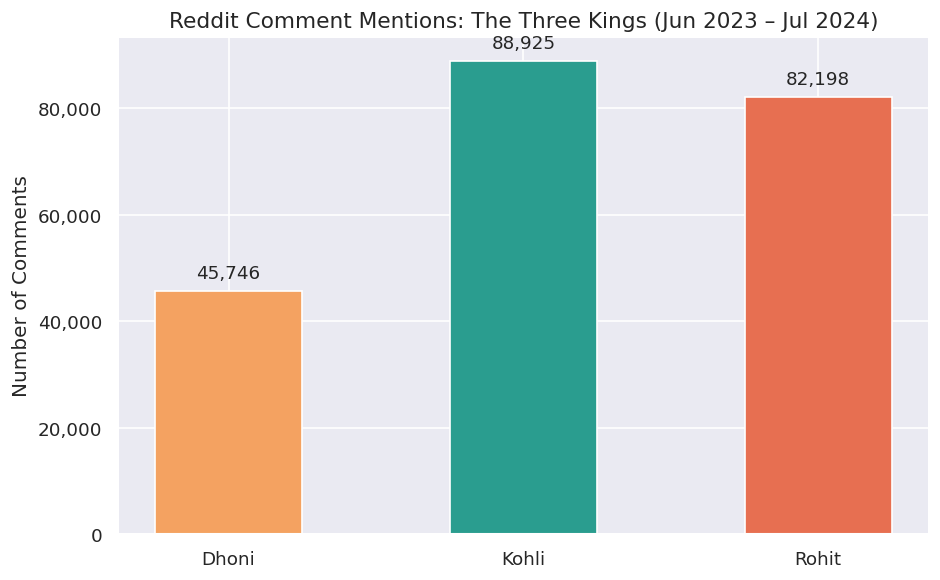

In [11]:
# Bar chart of player mentions in comments
fig, ax = plt.subplots(figsize=(8, 5))
com_counts = [com_mention_counts["Dhoni"][0], com_mention_counts["Kohli"][0], com_mention_counts["Rohit"][0]]

bars = ax.bar(players, com_counts, color=colors, width=0.5, edgecolor="white")
ax.bar_label(bars, labels=[f"{c:,}" for c in com_counts], padding=5, fontsize=11)
ax.set_title("Reddit Comment Mentions: The Three Kings (Jun 2023 – Jul 2024)", fontsize=13)
ax.set_ylabel("Number of Comments")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
save_figure(fig, "02_player_mentions_comments.png")
plt.show()


### 12. Monthly mention trends

How did player mentions change month by month?

In [12]:
# Monthly mention counts per player
monthly = subs.filter(col("mentions_any_king")).groupBy("year_num", "month_num").agg(
    ssum(col("mentions_dhoni").cast("int")).alias("Dhoni"),
    ssum(col("mentions_kohli").cast("int")).alias("Kohli"),
    ssum(col("mentions_rohit").cast("int")).alias("Rohit"),
).orderBy("year_num", "month_num").toPandas()

# Create a readable date label
monthly["date"] = pd.to_datetime(monthly[["year_num", "month_num"]].rename(
    columns={"year_num": "year", "month_num": "month"}
).assign(day=1))

print(monthly[["date", "Dhoni", "Kohli", "Rohit"]])


         date  Dhoni  Kohli  Rohit
0  2023-06-01    243    232    342
1  2023-07-01    227    178    383
2  2023-08-01    147    185    409
3  2023-09-01    207    262    440
4  2023-10-01    228    504    644
5  2023-11-01    291    787    701
6  2023-12-01    442    343    705
7  2024-01-01    260    523    847
8  2024-02-01    215    364    664
9  2024-03-01    609    611    807
10 2024-04-01    961    957   1100
11 2024-05-01    952    949    907
12 2024-06-01    273    875   1106
13 2024-07-01    241    530    855


### 13. Line chart — monthly mention trends

Saved to results/figures/02_monthly_mention_trends.png


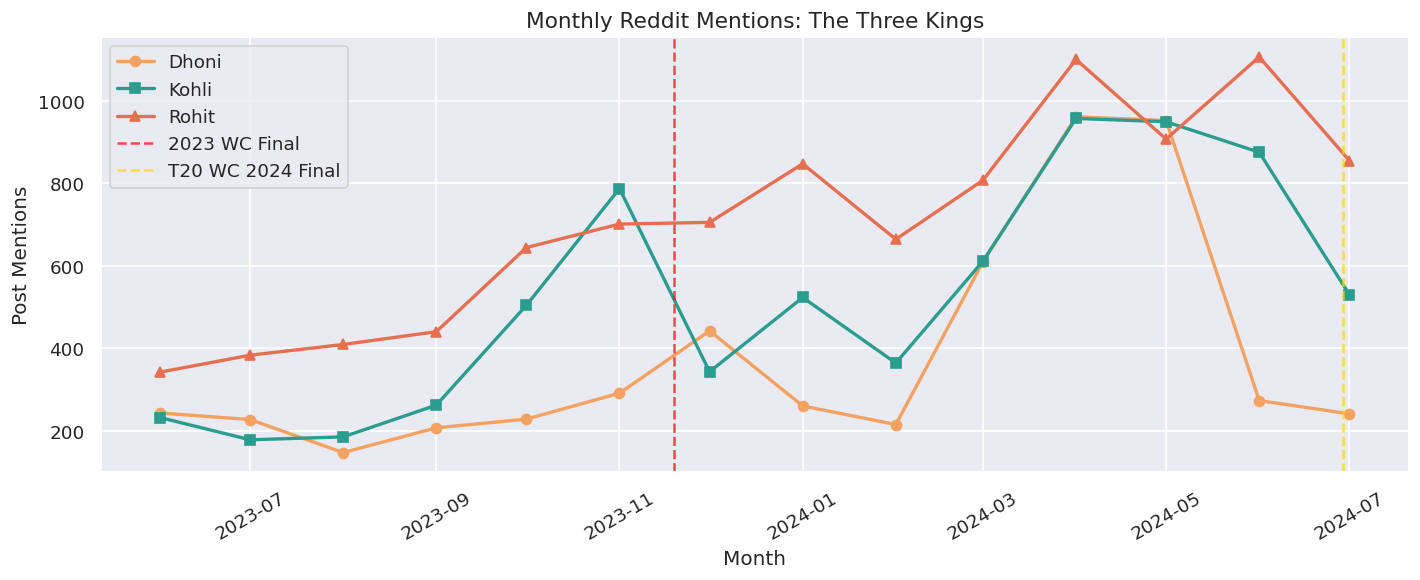

In [13]:
# Line chart of monthly mentions
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly["date"], monthly["Dhoni"], marker="o", label="Dhoni", color="#f4a261", linewidth=2)
ax.plot(monthly["date"], monthly["Kohli"], marker="s", label="Kohli", color="#2a9d8f", linewidth=2)
ax.plot(monthly["date"], monthly["Rohit"], marker="^", label="Rohit", color="#e76f51", linewidth=2)

# Mark key events
ax.axvline(EVENT_DATES["wc2023_final"], color="red", linestyle="--", alpha=0.7, label="2023 WC Final")
ax.axvline(EVENT_DATES["t20wc2024_final"], color="gold", linestyle="--", alpha=0.7, label="T20 WC 2024 Final")

ax.set_title("Monthly Reddit Mentions: The Three Kings", fontsize=13)
ax.set_ylabel("Post Mentions")
ax.set_xlabel("Month")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
save_figure(fig, "02_monthly_mention_trends.png")
plt.show()


### 14. Engagement by player mention

Which player's posts get the highest average score and comment count?

In [14]:
# Average score and comment count for posts mentioning each player
def player_engagement(df, player_col, player_name):
    return df.filter(col(player_col)).agg(
        count("*").alias("posts"),
        avg("score").alias("avg_score"),
        avg("num_comments").alias("avg_comments"),
    ).withColumn("player", F.lit(player_name))

dhoni_eng  = player_engagement(subs, "mentions_dhoni", "Dhoni")
kohli_eng  = player_engagement(subs, "mentions_kohli", "Kohli")
rohit_eng  = player_engagement(subs, "mentions_rohit", "Rohit")

engagement = dhoni_eng.union(kohli_eng).union(rohit_eng).toPandas()
print(engagement)
save_pandas_to_local(engagement, "02_player_engagement.csv")


   posts  avg_score  avg_comments player
0   5296  99.691088     11.056080  Dhoni
1   7300  91.580411     14.327123  Kohli
2   9910  72.376993     13.247830  Rohit
Saved to results/tables/02_player_engagement.csv


### 15. Bar chart — average score by player

Saved to results/figures/02_player_engagement_charts.png


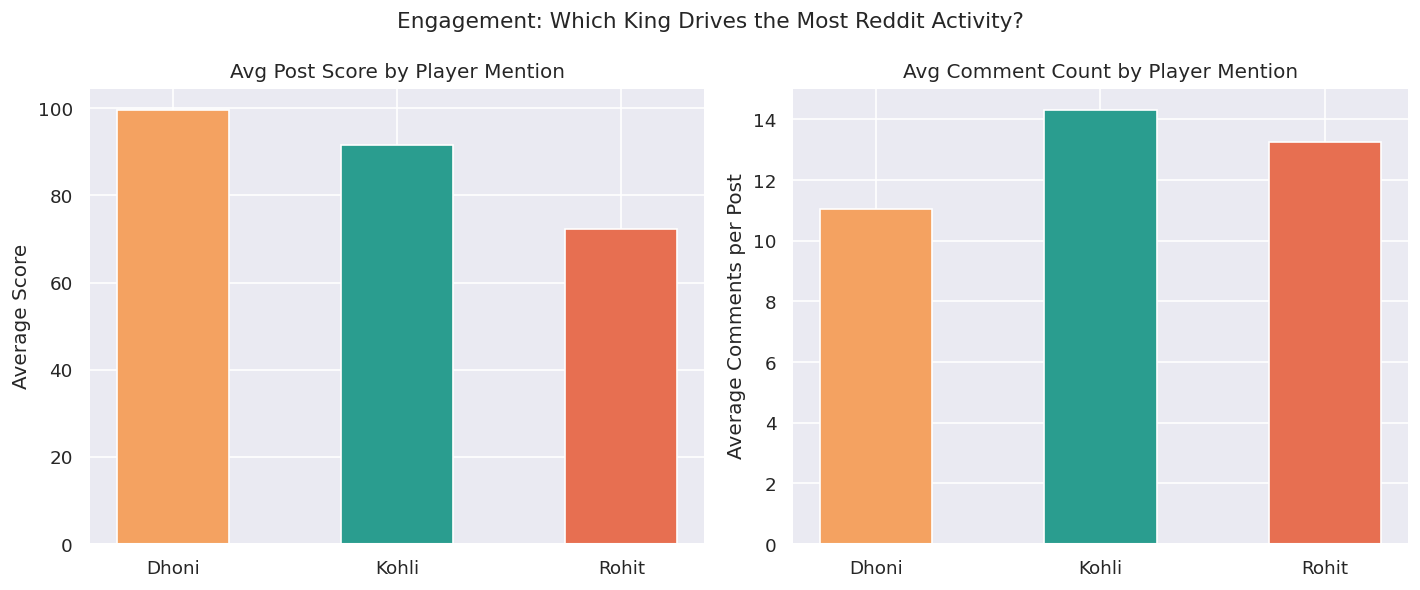

In [15]:
# Bar chart of average post score per player
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Avg score
axes[0].bar(engagement["player"], engagement["avg_score"], color=colors, width=0.5, edgecolor="white")
axes[0].set_title("Avg Post Score by Player Mention")
axes[0].set_ylabel("Average Score")

# Avg comments
axes[1].bar(engagement["player"], engagement["avg_comments"], color=colors, width=0.5, edgecolor="white")
axes[1].set_title("Avg Comment Count by Player Mention")
axes[1].set_ylabel("Average Comments per Post")

plt.suptitle("Engagement: Which King Drives the Most Reddit Activity?", fontsize=13)
plt.tight_layout()
save_figure(fig, "02_player_engagement_charts.png")
plt.show()


### 16. Top subreddits per player

Where does each player get talked about most?

In [16]:
# Top subreddits per player
def top_subs_for_player(df, player_col, player_name, n=10):
    return (
        df.filter(col(player_col))
        .groupBy("subreddit")
        .agg(count("*").alias("mentions"))
        .orderBy(col("mentions").desc())
        .limit(n)
        .toPandas()
        .assign(player=player_name)
    )

dhoni_subs = top_subs_for_player(subs, "mentions_dhoni", "Dhoni")
kohli_subs = top_subs_for_player(subs, "mentions_kohli", "Kohli")
rohit_subs = top_subs_for_player(subs, "mentions_rohit", "Rohit")

print("=== Dhoni ==="); print(dhoni_subs)
print("=== Kohli ==="); print(kohli_subs)
print("=== Rohit ==="); print(rohit_subs)


=== Dhoni ===
             subreddit  mentions player
0      CricketShitpost      2143  Dhoni
1         IndiaCricket      1117  Dhoni
2                  ipl       819  Dhoni
3              Cricket       516  Dhoni
4                  csk       509  Dhoni
5                  RCB        85  Dhoni
6                Dhoni        25  Dhoni
7        MumbaiIndians        24  Dhoni
8  KolkataKnightRiders        15  Dhoni
9   SunrisersHyderabad        11  Dhoni
=== Kohli ===
             subreddit  mentions player
0         IndiaCricket      2813  Kohli
1              Cricket      1552  Kohli
2      CricketShitpost       964  Kohli
3                  ipl       738  Kohli
4                  RCB       622  Kohli
5           ViratKohli       380  Kohli
6           PakCricket        67  Kohli
7  KolkataKnightRiders        37  Kohli
8        MumbaiIndians        32  Kohli
9                  csk        32  Kohli
=== Rohit ===
             subreddit  mentions player
0               HiTMAN      4107  Rohi

### 17. Stop Spark

In [17]:
# Stop Spark
spark.stop()
